In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from scipy.linalg import null_space
from scipy.linalg import solve as linsolve
from scipy.linalg import svd
from scipy.linalg import eig as eigenvalues
from utils import *
rc('text', usetex=True)
rc('font', family='sans-serif', serif=['Helvetica'], size=18)

## Example: 3-level internal states #

In [2]:
# def HR(Delta, Omega):
#     """3-level Rubidium Hamiltonian"""
#     Omega1 = Omega
#     Omega2 = Omega
#     Delta1 = Delta / 10
#     Delta2 = Delta
#     H = np.array([
#         [0, 0, Omega1 / 2],
#         [0, Delta1, Omega2 / 2],
#         [Omega1 / 2, Omega2 / 2, Delta2]
#     ], dtype=complex)
#     return H


# def LDiss1(r):
#     """Dissipator 1 for Rubidium"""
#     def func(gamma_d):
#         L = gamma_d * np.array([[0, 1, 0], [0, 0, 0], [0, 0, 0]], dtype=complex)
#         return lindblad_dissipator(L, r)
#     return func


# def LDiss2(r):
#     """Dissipator 2 for Rubidium"""
#     def func(gamma_d):
#         L = gamma_d * np.array([[0, 0, 1], [0, 0, 0], [0, 0, 0]], dtype=complex)
#         return lindblad_dissipator(L, r)
#     return func


# def LD1(r):
#     """Dephasing dissipator 1 for Rubidium"""
#     def func(gamma_phi):
#         L = gamma_phi * np.array([[0, 0, 0], [0, 1, 0], [0, 0, -1]], dtype=complex)
#         return lindblad_dissipator(L, r)
#     return func


# def LD2(r):
#     """Dephasing dissipator 2 for Rubidium"""
#     def func(gamma_phi):
#         L = gamma_phi * np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]], dtype=complex)
#         return lindblad_dissipator(L, r)
#     return func


# def diss(r):
#     """Total dissipator for Rubidium system"""
#     def func(Delta, Omega):
#         gamma_d = 2 * np.pi * 6.1
#         gamma_phi = 0.0
#         return (LDiss1(r)(gamma_d) + 
#                 LDiss2(r)(gamma_d) + 
#                 LD1(r)(gamma_phi) + 
#                 LD2(r)(gamma_phi))
#     return func

In [3]:
# H1 = HR
# range_Delta = [r'$\Delta$', -2 * np.pi * 100, 2 * np.pi * 100] # 2π × [-100, 100] MHz
# range_Omega = [r'$\Omega$', 2 * np.pi, 2 * np.pi * 10] # 2π × [1, 10] MHz

# p1_grid, p2_grid, curvature_data, max_val = old_heat_curvature(
#     H1, H1, diss,
#     ranges=[range_Delta, range_Omega],
#     points=100
# )

# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_axes([0.1, 0.08, 0.8, 0.75])
# cp = ax.contourf(p2_grid / (2 * np.pi), p1_grid / (2 * np.pi), np.transpose(curvature_data), levels=20, cmap='coolwarm')
# cax = fig.add_axes([0.1, 0.87, 0.8, 0.05])
# mantissa, exp = f"{max_val:.2e}".split('e')
# cbar = fig.colorbar(cp, cax=cax, orientation='horizontal', label=rf'$\mathcal{{F}}^{{Q}} \; \times {mantissa} \times 10^{{{int(exp)}}} \; \mathrm{{[J/MHz^2]}}$')
# cbar.ax.xaxis.set_label_position('top')
# cbar.ax.xaxis.tick_top()
# ax.set_xlabel(r'$\Omega / 2 \pi \; \mathrm{[MHz]}$')
# ax.set_ylabel(r'$\Delta / 2 \pi \; \mathrm{[MHz]}$')
# plt.savefig('figures/3lvl_Rb.pdf', bbox_inches='tight')
# plt.show()

# # Liouvillian Gap Example
# gap_min = liouvillian_gap(
#     H1,
#     diss,
#     params=[r'$\Delta$', r'$\Omega$'],
#     ranges=[range_Delta,range_Omega],
#     points=100
# )

# # Reversible and Dissipative Heat Example
# # Cycle path goes over the whole parameter range
# q_geo, q_diss = compute_cycle_heats(
#     H1,
#     H1,
#     diss,
#     p_min=[range_Delta[1], range_Omega[1]],
#     p_max=[range_Delta[2], range_Omega[2]],
#     tau= 100 / (gap_min),  # Long cycle time to approach adiabatic limit
#     points=100,
#     clockwise=True
# )

# kB = 1.380649e-23  # Boltzmann constant in J/K
# hbar = 1.0545718e-34  # Reduced Planck constant in J*s
# print("Temperature change over the cycle:", (q_geo + q_diss) * hbar / kB, "K")

In [4]:
# q_geo, q_diss = compute_cycle_heats(
#     H1,
#     H1,
#     diss,
#     p_min=[range_Delta[1], range_Omega[1]],
#     p_max=[range_Delta[2], range_Omega[2]],
#     tau= 1 / (gap_min),  # Long cycle time to approach adiabatic limit
#     points=100,
#     clockwise=True
# )

# kB = 1.380649e-23  # Boltzmann constant in J/K
# hbar = 1.0545718e-34  # Reduced Planck constant in J*s
# print("Temperature change over the cycle:", (q_geo + q_diss) * hbar / kB, "K")

## TLS-Mot model ##

In [5]:
N_mot = 4

def H_motion_tls(delta_0, omega_rabi, omega_mot):
    """
    Motion-TLS Hamiltonian.
    delta_0: detuning (-50 to 50 KHz)
    omega_rabi: Rabi frequency (2 pi 10-1e4 Hz)
    omega_mot: Motional frequency (2 pi 50-500 Hz)
    """
    a_diag_vals = np.sqrt(np.arange(1, N_mot))
    a = np.diag(a_diag_vals, k=1)
    adag = a.T.conj()
    
    # Physical constants (using higher precision)
    x0 = np.longdouble(1e-5) # 0-10 \mu m
    mu_B = np.longdouble(9.27e-24) #  J/T
    gF = np.longdouble(0.5)
    B0 = np.longdouble(1e-3) # T
    dB = np.longdouble(10.0) # 1000 G/cm = 10 T/m
    hbar = np.longdouble(1.05e-34) # J s
    m = np.longdouble(1.44e-25) # kg
    
    # Oscillator length scale
    x_ho = np.sqrt(hbar / (np.longdouble(2) * m * omega_mot))
    eta = gF * mu_B * x_ho * dB / hbar
    
    # Hamiltonian components
    H_mot = omega_mot * (np.kron(sigma0, adag @ a) - x0 / x_ho * np.kron(sigma0, adag + a))
    H_spin = np.longdouble(0.5) * np.kron(delta_0 * sigma3 + omega_rabi * sigma1, np.eye(N_mot))
    H_coup = np.kron(sigma3, -0.5 * eta * (adag + a))

    return H_mot + H_spin + H_coup

def H_motion_tls_ref(delta_0, omega_rabi, omega_mot):
    """Reference Hamiltonian for Motion-TLS (photon number operator)"""
    a_diag_vals = np.sqrt(np.arange(1, N_mot))
    a = np.diag(a_diag_vals, k=1)
    adag = a.T.conj()

    hbar = np.longdouble(1.05e-34) # J s
    m = np.longdouble(1.44e-25) # kg
    x0 = np.longdouble(1e-5) # 0-10 \mu m
    x_ho = np.sqrt(hbar / (np.longdouble(2) * m * omega_mot))

    H_mot = omega_mot * (np.kron(sigma0, adag @ a) - x0 / x_ho * np.kron(sigma0, adag + a))
    return H_mot


def diss_motion_tls(r):
    """Dissipator for Motion-TLS system"""
    a_diag_vals = np.sqrt(np.arange(1, N_mot))
    a = np.diag(a_diag_vals, k=1)
    adag = a.T.conj()
    
    def func(delta_0, omega_rabi, omega_mot):

        gamma_up = np.longdouble(1e5) # Hz
        gamma_phi = np.longdouble(100.0) # Hz
        gamma_m = np.longdouble(50.0) # Hz

        hbar = np.longdouble(1.05e-34) # J s
        m = np.longdouble(1.44e-25) # kg
        x_ho = np.sqrt(hbar / (np.longdouble(2) * m * omega_mot))
        k_0 = 2 * np.pi / (780e-9) # 780 nm wavelength
        delta_k_avg = np.longdouble(3 * k_0 / 32) # Average momentum kick

        L_up_right = np.sqrt(gamma_up) * np.kron(sigma_up, np.exp(1j * 4 * delta_k_avg * x_ho * (adag + a)))
        L_up_left = np.sqrt(gamma_up) * np.kron(sigma_up, np.exp(-1j * 4 * delta_k_avg * x_ho * (adag + a)))

        L_DP = np.sqrt(gamma_phi/2) * np.kron(sigma3, np.eye(N_mot))
        L_mot = np.sqrt(gamma_m) * np.kron(np.eye(2), a + adag)
        
        return (lindblad_dissipator(L_up_right, r) +
                lindblad_dissipator(L_up_left, r) +
                lindblad_dissipator(L_DP, r) +
                lindblad_dissipator(L_mot, r) )
        
    return func

## Example: Motion-TLS Coupled System with $\lambda=(\Omega,\Delta)$ ##

Computing Liouvillian Gap for 8x8 system...
Liouvillian gap between 8.80e-03 and 1.01e+00.


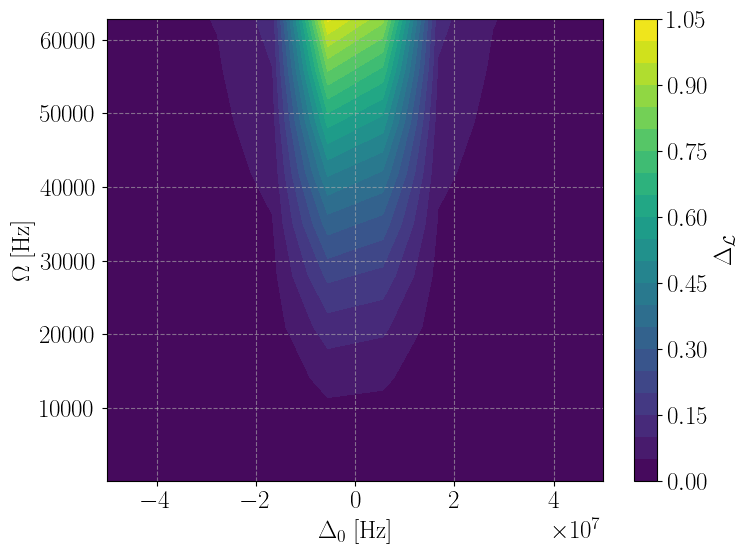

In [6]:
Delta0_range = [r'$\Delta_0$', -50 * 1e6, 50 * 1e6] # Hz
Omega_range = [r'$\Omega$', 2 * np.pi * 20, 2 * np.pi * 1e4] # Hz

def H_ex1(delta_0, omega_rabi):
    return H_motion_tls(delta_0, omega_rabi, 2 * np.pi * 500)
def H_ref_ex1(delta_0, omega_rabi):
    return H_motion_tls_ref(delta_0, omega_rabi, 2 * np.pi * 500)
def diss_ex1(r):
    def func(delta_0, omega_rabi):  # Then returns a function for parameters
        return diss_motion_tls(r)(delta_0, omega_rabi, 2 * np.pi * 500)
    return func

# p1_grid_mtls, p2_grid_mtls, curvature_mtls, max_val_mtls = old_heat_curvature(
#     H_ex1, H_ref_ex1, diss_ex1,
#     ranges=[Delta0_range, Omega_range],
#     points=10
# )

# # Plot Heat Curvature
# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_axes([0.1, 0.08, 0.8, 0.75])
# cp = ax.contourf(p1_grid_mtls, p2_grid_mtls, curvature_mtls, levels=20, cmap='coolwarm')
# cax = fig.add_axes([0.1, 0.87, 0.8, 0.05])
# mantissa, exp = f"{max_val_mtls:.2e}".split('e')
# cbar = fig.colorbar(cp, cax=cax, orientation='horizontal',
#     label=rf'$\mathcal{{F}}^Q \times {mantissa} \times 10^{{{int(exp)}}} \; \mathrm{{[J/Hz^2]}}$')
# cbar.ax.xaxis.set_label_position('top')
# cbar.ax.xaxis.tick_top()
# ax.set_xlabel(r'$\Delta_0 \; \mathrm{[Hz]}$')
# ax.set_ylabel(r'$\Omega \; \mathrm{[Hz]}$')
# plt.savefig('figures/motion_tls_Delta_Omega.pdf', bbox_inches='tight')
# plt.show()

# Liouvillian Gap
gap_min = liouvillian_gap(
    H_ex1,
    diss_ex1,
    params=[r'$\Delta_0 \; \mathrm{[Hz]}$', r'$\Omega \; \mathrm{[Hz]}$'],
    ranges=[Delta0_range, Omega_range],
    points=10
)

In [7]:
# Cycle heats
q_geo_mtls, q_diss_mtls = compute_cycle_heats(
    H_ex1,
    H_ref_ex1,
    diss_ex1,
    p_min=[Delta0_range[1], Omega_range[1]],
    p_max=[Delta0_range[2], Omega_range[2]],
    tau= 1 / gap_min,  # Long cycle time to approach adiabatic limit
    points=100,
    clockwise=True
)

kB = 1.380649e-23  # Boltzmann constant in J/K
hbar = 1.0545718e-34  # Reduced Planck constant in J*s
print("q_rev:",  (q_geo_mtls) * hbar / kB, "K")
print("q_diss:",  (q_diss_mtls) * hbar / kB, "K")
print("q_tot:", (q_geo_mtls + q_diss_mtls) * hbar / kB, "K")

Starting cycle integration for d=8 system...


--- Results ---
Geometric Heat: -424589.58554687304
Dissipated Heat: 71.15007377788841
Net: -424518.43547309516
q_rev: -3.2431139521443888987e-06 K
q_diss: 5.434608026665762071e-10 K
q_tot: -3.2425704913417223224e-06 K


## Example: TLS-Mot with $\lambda=(\Omega, \omega)$ ##

Computing Liouvillian Gap for 8x8 system...
Liouvillian gap between 1.76e-03 and 1.48e+00.


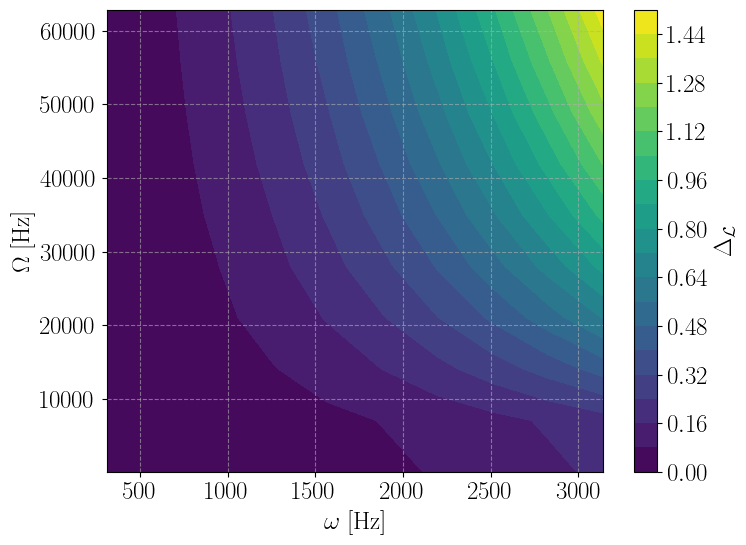

In [8]:
omega_mot_range = [r'$\omega$', 2 * np.pi * 50, 2 * np.pi * 500] # Hz
Omega_range = [r'$\Omega$', 2 * np.pi * 20, 2 * np.pi * 1e4] # Hz

def H_ex2(omega_rabi, omega_mot):
    return H_motion_tls(50 * 1e3, omega_rabi, omega_mot)
def H_ref_ex2(omega_rabi, omega_mot):
    return H_motion_tls_ref(50 * 1e3, omega_rabi, omega_mot)
def diss_ex2(r):
    def func(omega_rabi, omega_mot):  # Then returns a function for parameters
        return diss_motion_tls(r)(50 * 1e3, omega_rabi, omega_mot)
    return func

# Liouvillian Gap
gap_min = liouvillian_gap(
    H_ex2,
    diss_ex2,
    params=[r'$\omega \; \mathrm{[Hz]}$', r'$\Omega \; \mathrm{[Hz]}$'],
    ranges=[omega_mot_range,Omega_range],
    points=10
)

In [16]:
# Cycle heats
q_geo_mtls, q_diss_mtls = compute_cycle_heats(
    H_ex2,
    H_ref_ex2,
    diss_ex2,
    p_min=[omega_mot_range[1], 1e4],
    p_max=[omega_mot_range[2], Omega_range[2]],
    tau=100/gap_min,
    points=100,
    clockwise=True
)

kB = 1.380649e-23  # Boltzmann constant in J/K
hbar = 1.0545718e-34  # Reduced Planck constant in J*s
print("q_rev:",  (q_geo_mtls) * hbar / kB, "K")
print("q_diss:",  (q_diss_mtls) * hbar / kB, "K")
print("q_tot:", (q_geo_mtls + q_diss_mtls) * hbar / kB, "K")

Starting cycle integration for d=8 system...
--- Results ---
Geometric Heat: -203461.75888657823
Dissipated Heat: -343511640.1200781
Net: -343715101.87896466
q_rev: -1.5540882099663620912e-06 K
q_diss: -0.0026238217580455493523 K
q_tot: -0.0026253758462555157144 K


## Exmaple: TLS-Mot $\lambda=(\Delta,\omega)$ ##

Computing Liouvillian Gap for 8x8 system...
Liouvillian gap between 7.46e+01 and 1.52e+02.


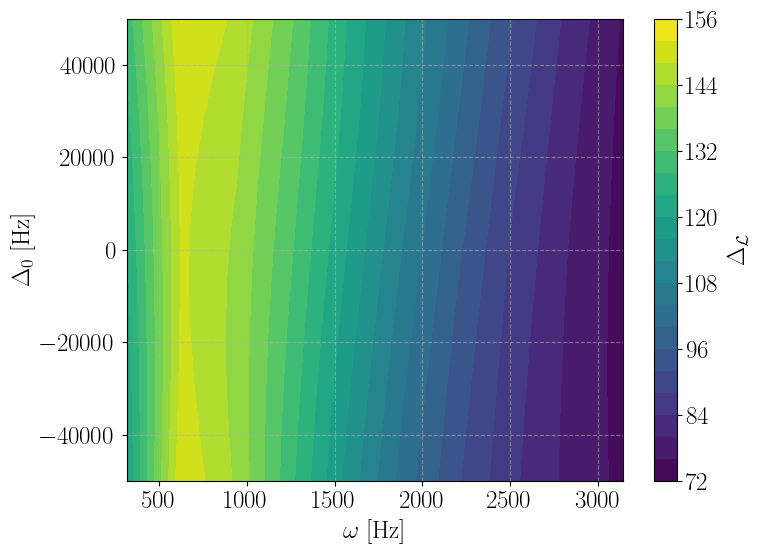

In [10]:
omega_mot_range = [r'$\omega$', 2 * np.pi * 50, 2 * np.pi * 500] # Hz
delta_range = [r'$\Delta_0$', -50 * 1e3, 50 * 1e3] # Hz

def H_ex3(omega_mot, delta_0):
    return H_motion_tls(delta_0, 2 * np.pi * 1e4, omega_mot)
def H_ref_ex3(omega_mot, delta_0):
    return H_motion_tls_ref(delta_0, 2 * np.pi * 1e4, omega_mot)
def diss_ex3(r):
    def func(omega_mot, delta_0):  # Then returns a function for parameters
        return diss_motion_tls(r)(delta_0, 2 * np.pi * 1e4, omega_mot)
    return func

# Liouvillian Gap
gap_min = liouvillian_gap(
    H_ex3,
    diss_ex3,
    params=[r'$\omega \; \mathrm{[Hz]}$', r'$\Delta_0 \; \mathrm{[Hz]}$'],
    ranges=[omega_mot_range,delta_range],
    points=10
)

In [17]:
# Cycle heats
q_geo_mtls, q_diss_mtls = compute_cycle_heats(
    H_ex3,
    H_ref_ex3,
    diss_ex3,
    p_min=[omega_mot_range[1], delta_range[1]],
    p_max=[omega_mot_range[2], delta_range[2]],
    tau=100 / gap_min,
    points=100,
    clockwise=True
)

kB = 1.380649e-23  # Boltzmann constant in J/K
hbar = 1.0545718e-34  # Reduced Planck constant in J*s
print("q_rev:",  (q_geo_mtls) * hbar / kB, "K")
print("q_diss:",  (q_diss_mtls) * hbar / kB, "K")
print("q_tot:", (q_geo_mtls + q_diss_mtls) * hbar / kB, "K")

Starting cycle integration for d=8 system...
--- Results ---
Geometric Heat: -46248.47543019603
Dissipated Heat: -6761.58858095328
Net: -53010.064011149305
q_rev: -3.5325660599962476007e-07 K
q_diss: -5.164658534265657788e-08 K
q_tot: -4.0490319134228133796e-07 K


## Combined figure ##

/tmp/ipykernel_12062/1740430050.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


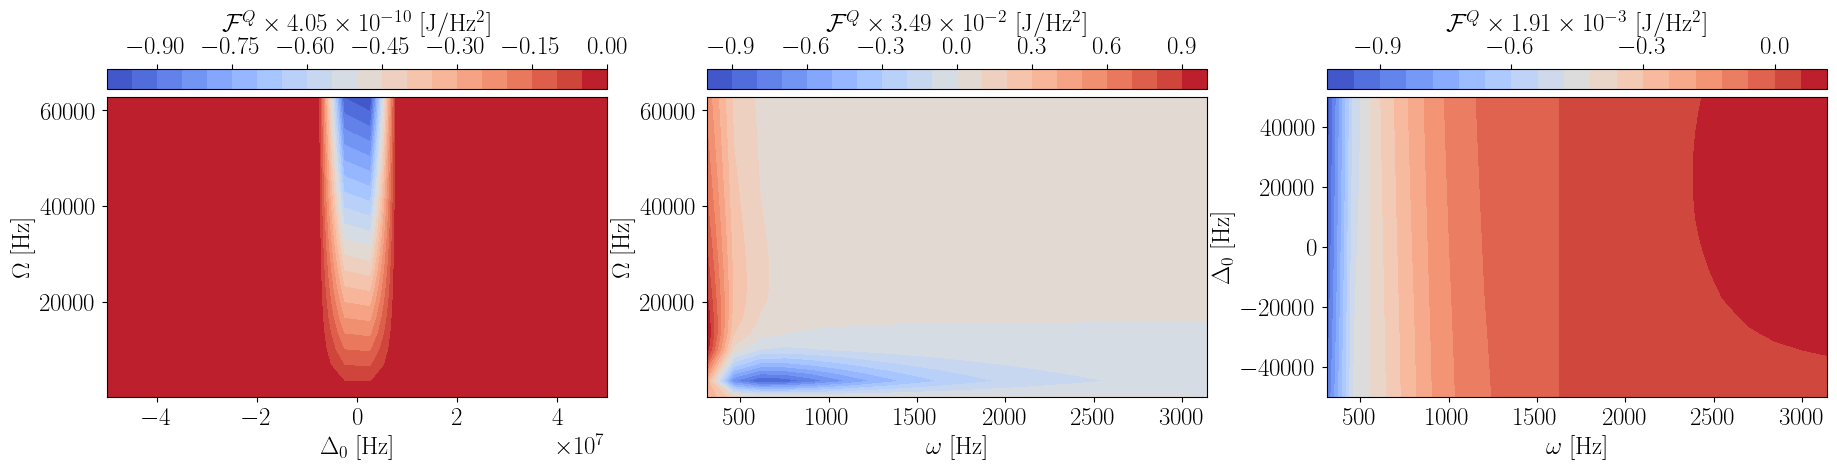

In [12]:
fig = plt.figure(figsize=(20, 4))

# Plot 2: Motion-TLS Delta-Omega (need to recalculate)
Delta0_range = [r'$\Delta_0$', -50 * 1e6, 50 * 1e6]
Omega_range_v1 = [r'$\Omega$', 2 * np.pi * 20, 2 * np.pi * 1e4]

def H_ex1_v(delta_0, omega_rabi):
    return H_motion_tls(delta_0, omega_rabi, 2 * np.pi * 500)
def H_ref_ex1_v(delta_0, omega_rabi):
    return H_motion_tls_ref(delta_0, omega_rabi, 2 * np.pi * 500)
def diss_ex1_v(r):
    def func(delta_0, omega_rabi):
        return diss_motion_tls(r)(delta_0, omega_rabi, 2 * np.pi * 500)
    return func

p1_v, p2_v, curv_v, max_val_v = old_heat_curvature(
    H_ex1_v, H_ref_ex1_v, diss_ex1_v,
    ranges=[Delta0_range, Omega_range_v1],
    points=20
)

ax1 = fig.add_axes([0.04, 0.1, 0.25, 0.75])
cp1 = ax1.contourf(p1_v, p2_v, curv_v, levels=20, cmap='coolwarm')
ax1.set_xlabel(r'$\Delta_0 \; \mathrm{[Hz]}$')
ax1.set_ylabel(r'$\Omega \; \mathrm{[Hz]}$')
cax1 = fig.add_axes([0.04, 0.87, 0.25, 0.05])
mantissa, exp = f"{max_val_v:.2e}".split('e')
cbar1 = fig.colorbar(cp1, cax=cax1, orientation='horizontal',
    label=rf'$\mathcal{{F}}^Q \times {mantissa} \times 10^{{{int(exp)}}} \; \mathrm{{[J/Hz^2]}}$')
cbar1.ax.xaxis.set_label_position('top')
cbar1.ax.xaxis.tick_top()

# Plot 3: Motion-TLS Omega-omega (need to recalculate)
omega_mot_range_v2 = [r'$\omega$', 2 * np.pi * 50, 2 * np.pi * 500]
Omega_range_v2 = [r'$\Omega$', 2 * np.pi * 20, 2 * np.pi * 1e4]

def H_ex2_v(omega_rabi, omega_mot):
    return H_motion_tls(50 * 1e3, omega_rabi, omega_mot)
def H_ref_ex2_v(omega_rabi, omega_mot):
    return H_motion_tls_ref(50 * 1e3, omega_rabi, omega_mot)
def diss_ex2_v(r):
    def func(omega_rabi, omega_mot):
        return diss_motion_tls(r)(50 * 1e3, omega_rabi, omega_mot)
    return func

p1_v2, p2_v2, curv_v2, max_val_v2 = old_heat_curvature(
    H_ex2_v, H_ref_ex2_v, diss_ex2_v,
    ranges=[omega_mot_range_v2, Omega_range_v2],
    points=20
)

ax2 = fig.add_axes([0.34, 0.1, 0.25, 0.75])
cp2 = ax2.contourf(p1_v2, p2_v2, curv_v2, levels=20, cmap='coolwarm')
ax2.set_xlabel(r'$\omega \; \mathrm{[Hz]}$')
ax2.set_ylabel(r'$\Omega \; \mathrm{[Hz]}$')
cax2 = fig.add_axes([0.34, 0.87, 0.25, 0.05])
mantissa, exp = f"{max_val_v2:.2e}".split('e')
cbar2 = fig.colorbar(cp2, cax=cax2, orientation='horizontal',
    label=rf'$\mathcal{{F}}^Q \times {mantissa} \times 10^{{{int(exp)}}} \; \mathrm{{[J/Hz^2]}}$')
cbar2.ax.xaxis.set_label_position('top')
cbar2.ax.xaxis.tick_top()

# Plot 4: Motion-TLS Delta-omega (need to recalculate)
omega_mot_range_v3 = [r'$\omega$', 2 * np.pi * 50, 2 * np.pi * 500]
delta_range_v3 = [r'$\Delta_0$', -50 * 1e3, 50 * 1e3]

def H_ex3_v(omega_mot, delta_0):
    return H_motion_tls(delta_0, 2 * np.pi * 1e4, omega_mot)
def H_ref_ex3_v(omega_mot, delta_0):
    return H_motion_tls_ref(delta_0, 2 * np.pi * 1e4, omega_mot)
def diss_ex3_v(r):
    def func(omega_mot, delta_0):
        return diss_motion_tls(r)(delta_0, 2 * np.pi * 1e4, omega_mot)
    return func

p1_v3, p2_v3, curv_v3, max_val_v3 = old_heat_curvature(
    H_ex3_v, H_ref_ex3_v, diss_ex3_v,
    ranges=[omega_mot_range_v3, delta_range_v3],
    points=20
)

ax3 = fig.add_axes([0.65, 0.1, 0.25, 0.75])
cp3 = ax3.contourf(p1_v3, p2_v3, curv_v3, levels=20, cmap='coolwarm')
ax3.set_xlabel(r'$\omega \; \mathrm{[Hz]}$')
ax3.set_ylabel(r'$\Delta_0 \; \mathrm{[Hz]}$')
cax3 = fig.add_axes([0.65, 0.87, 0.25, 0.05])
mantissa, exp = f"{max_val_v3:.2e}".split('e')
cbar3 = fig.colorbar(cp3, cax=cax3, orientation='horizontal',
    label=rf'$\mathcal{{F}}^Q \times {mantissa} \times 10^{{{int(exp)}}} \; \mathrm{{[J/Hz^2]}}$')
cbar3.ax.xaxis.set_label_position('top')
cbar3.ax.xaxis.tick_top()
cbar3.locator.set_params(nbins=4)

plt.tight_layout()
plt.savefig('figures/motion_tls_combined.pdf', bbox_inches='tight')
plt.show()